In [ ]:
!pip install -q datasets torchcfm

In [ ]:
from datasets import load_dataset

ds = load_dataset("bahjat-kawar/tedbench", split="val")

In [ ]:
import torch
from sentence_transformers import SentenceTransformer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
text_encoder = SentenceTransformer("all-mpnet-base-v2").to(device)

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

In [ ]:
from torch.utils.data import Dataset, DataLoader

class TextGuidedImageGenerationDataset(Dataset):
    def __init__(self, dataset, transform, text_encoder, device):
        self.dataset = dataset
        self.transform = transform
        self.text_encoder = text_encoder
        self.device = device
        self.original_images = dataset["original_image"]
        self.captions = dataset["caption"]
        self.edited_images = dataset["edited_image"]
        self.embed_captions = text_encoder.encode(
            self.captions, convert_to_tensor=True, device=self.device
        )

    def __len__(self):
        return len(self.captions)

    def __getitem__(self, idx):
        ### Your code here

        return {
            "original_image": original_image,
            "edited_image": edited_image,
            "caption": caption,
            "caption_embedding": caption_embedding,
        }

train_ds = TextGuidedImageGenerationDataset(
    ds, transform, text_encoder, device
)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

In [ ]:
sample = next(iter(train_ds))

## **Model**

In [ ]:
import math
import torch.nn as nn
from torchcfm.models.unet import UNetModel

def timestep_embedding(timesteps, dim, max_period=10000):
    """Create sinusoidal timestep embeddings.

    :param timesteps: a 1-D Tensor of N indices, one per batch element. These may be fractional.
    :param dim: the dimension of the output.
    :param max_period: controls the minimum frequency of the embeddings.
    :return: an [N x dim] Tensor of positional embeddings.
    """
    half = dim // 2
    freqs = torch.exp(
        -math.log(max_period)
        * torch.arange(start=0, end=half, dtype=torch.float32, device=timesteps.device)
        / half
    )
    args = timesteps[:, None].float() * freqs[None]
    embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2:
        embedding = torch.cat([embedding, torch.zeros_like(embedding[:, :1])], dim=-1)
    return embedding

class UNetModelWithTextEmbedding(UNetModel):
    def __init__(self, dim, num_channels, num_res_blocks, embedding_dim, *args, **kwargs):
        super().__init__(dim, num_channels, num_res_blocks, *args, **kwargs)

        self.image_encoder = nn.Sequential(
            nn.Conv2d(3, num_channels, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(num_channels, num_channels*2, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(num_channels*2, num_channels*4, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.embedding_layer = nn.Linear(embedding_dim, num_channels*4)
        self.fc = nn.Linear(num_channels*12, num_channels*4)

    def forward(self, t, x, text_embeddings=None, original_image=None):
        """Apply the model to an input batch, incorporating text embeddings."""
        timesteps = t

        while timesteps.dim() > 1:
            timesteps = timesteps[:, 0]
        if timesteps.dim() == 0:
            timesteps = timesteps.repeat(x.shape[0])

        hs = []
        emb = self.time_embed(timestep_embedding(timesteps, self.model_channels))

        if (text_embeddings is not None) and (original_image is not None):
            ### Your code here

        h = x.type(self.dtype)
        for module in self.input_blocks:
            h = module(h, emb)
            hs.append(h)
        h = self.middle_block(h, emb)
        for module in self.output_blocks:
            h = torch.cat([h, hs.pop()], dim=1)
            h = module(h, emb)
        h = h.type(x.dtype)
        return self.out(h)

In [ ]:
model = UNetModelWithTextEmbedding(
    dim=(3, 64, 64), num_channels=32, num_res_blocks=1, embedding_dim=768
).to(device)
optimizer = torch.optim.Adam(model.parameters())

In [ ]:
from tqdm import tqdm

n_epochs = 5000
for epoch in tqdm(range(n_epochs)):
    ### Your code here

 10%|█         | 502/5000 [00:39<05:36, 13.38it/s]

Epoch [500/5000], Loss: 0.0336


 20%|██        | 1002/5000 [01:17<04:55, 13.52it/s]

Epoch [1000/5000], Loss: 0.0144


 30%|███       | 1502/5000 [01:55<04:26, 13.14it/s]

...

Epoch [4000/5000], Loss: 0.0286


 90%|█████████ | 4502/5000 [05:45<00:36, 13.47it/s]

Epoch [4500/5000], Loss: 0.0032


100%|██████████| 5000/5000 [06:23<00:00, 13.04it/s]

Epoch [5000/5000], Loss: 0.0016


In [ ]:
model.eval()
def euler_method(model, text_embedding, t_steps, dt, noise, original_image):
    y = noise
    y_values = [y]
    with torch.no_grad():
        ### Your code here
    return torch.stack(y_values)

# Initial random image and class (optional)
noise = torch.randn_like(original_image, device=device)
text_embedding = caption_embedding

# Time parameters
t_steps = torch.linspace(0, 1, 100, device=device)
dt = t_steps[1] - t_steps[0]

# Solve the ODE using Euler method
results = euler_method(model, text_embedding, t_steps, dt, noise, original_image)

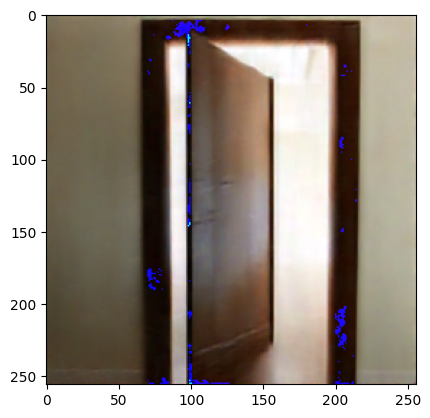

In [ ]:
import matplotlib.pyplot as plt
from torchvision.transforms import ToPILImage
from torchvision.utils import make_grid

grid = make_grid(
    results[-1].clip(-1, 1), value_range=(-1, 1), padding=0, nrow=10
)
img = ToPILImage()(grid)
plt.imshow(img)
plt.savefig("text_guided.png", dpi=300)
plt.show()